<a href="https://colab.research.google.com/github/fboldt/aulasann/blob/main/aula02b%20perceptron%20vetorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import numpy as np

def createDataset(n=20):
  X = np.random.rand(n,2)
  coefs = np.array([1, 1])
  intercept = 1
  labels = X @ coefs - intercept
  y = np.array(labels>0, dtype=int)*2-1
  return X, y

X, y = createDataset()
print(X)
print(y)

[[0.78019343 0.84822159]
 [0.69216878 0.44056631]
 [0.60614199 0.66202198]
 [0.47672573 0.54204385]
 [0.7461111  0.01893793]
 [0.6065733  0.435086  ]
 [0.75295568 0.47766191]
 [0.07180149 0.08440745]
 [0.64647152 0.46276951]
 [0.95252713 0.83099628]
 [0.74947845 0.82567423]
 [0.26043976 0.72253777]
 [0.45985729 0.86798639]
 [0.21107237 0.04054585]
 [0.87159312 0.76289216]
 [0.11142677 0.30233227]
 [0.10352009 0.82903887]
 [0.60640317 0.65858996]
 [0.8663473  0.184016  ]
 [0.91813453 0.47377763]]
[ 1  1  1  1 -1  1  1 -1  1  1  1 -1  1 -1  1 -1 -1  1  1  1]


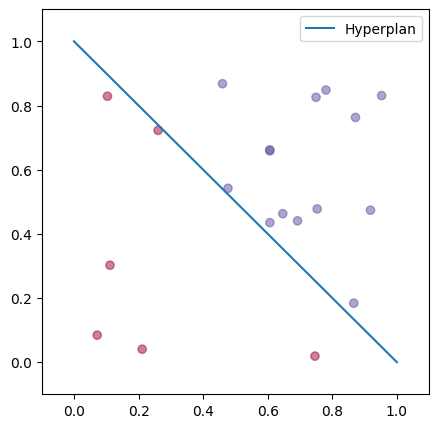

In [41]:
import matplotlib.pyplot as plt

def plotDataset(X, y):
  plt.figure(figsize=(5,5))
  plt.scatter(X[:,0], X[:,1], c=y, cmap="Spectral", alpha=0.5)
  plt.xlim(-0.1,1.1)
  plt.ylim(-0.1,1.1)

def plotHyperplan(vector, intercept, legend="Hyperplan"):
  xs = np.array([0,1])
  ys = -(vector[0]*xs + intercept)/vector[1]
  plt.plot(xs, ys, label=legend)
  plt.legend()

plotDataset(X, y)
plotHyperplan(np.array([1, 1]), -1)
plt.show()

Accuracy: 1.0
Weights: [24.75105464 16.55029562], Bias: -19.041165135196792


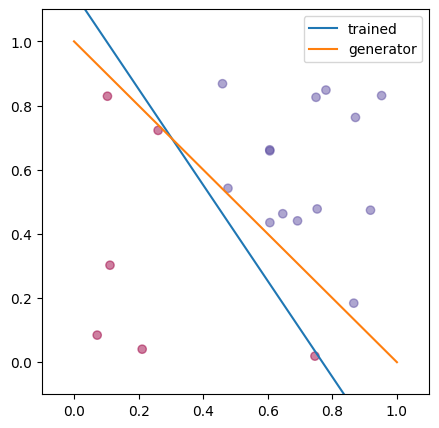

In [81]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

class Perceptron(BaseEstimator, ClassifierMixin):
  def __init__(self, max_iter=1000):
    self.max_iter = max_iter

  def fit(self, X, y):
    self.w_ = np.random.rand(X.shape[1])
    self.b_ = np.random.rand()
    for _ in range(self.max_iter):
      cost = 0
      y_pred = self.predict(X)
      error = y - y_pred
      self.w_ += np.dot(X.T, error)
      self.b_ += np.sum(error)
      cost = np.sum(error**2)
      if cost == 0:
        break
    return self

  def predict(self, X):
    logits = X @ self.w_ + self.b_
    y_pred = np.sign(logits)
    return y_pred

clf = Perceptron()
clf.fit(X, y)
y_pred = clf.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
print(f"Weights: {clf.w_}, Bias: {clf.b_}")
plotDataset(X, y)
plotHyperplan(clf.w_, clf.b_, legend="trained")
plotHyperplan(np.array([1, 1]), -1, legend="generator")
plt.show()

Accuracy: 0.897


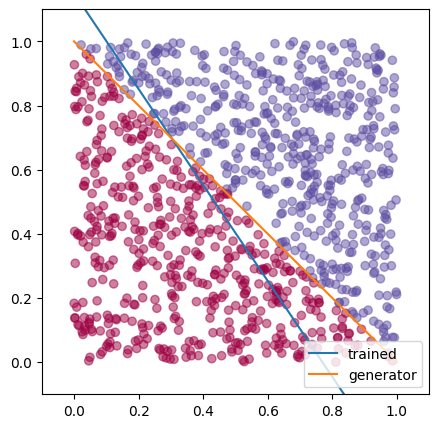

In [83]:
X_test, y_test = createDataset(1000)
y_pred = clf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
plotDataset(X_test, y_test)
plotHyperplan(clf.w_, clf.b_, legend="trained")
plotHyperplan(np.array([1, 1]), -1, legend="generator")
plt.show()